## 1. What this notebook computes

This notebook studies ONE wave of the field dirac16complex at a time: a plane wave
with fixed momenta along the seven directions of a slice $x_4 = $ const, in flat
4+4 space (or, which is the same thing at one point, with the coefficients of the
field equation frozen there). It

- builds, from the author's gamma matrices, the matrix $B = -iC\gamma^{(x_4)}$ that
  appears in the charge density $\Psi^\dagger B \Psi$ and later in the canonical
  anticommutator, and checks that $B$ is Hermitian, squares to 1 and has eight
  eigenvalues $+1$ and eight eigenvalues $-1$;
- writes the field equation of one plane wave as $i\,du/dx_4 = h\,u$ with a
  $16 \times 16$ matrix $h$, the *mode Hamiltonian*;
- proves with exact algebra (sympy) that $h^2 = w^2 I_{16}$ with
  $w^2 = m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2$, and that
  $B h = h^\dagger B$;
- follows the eigenvalues of $h$ as the momentum $k_5$ along the extra time $x_5$
  grows: they are real (oscillation) while $w^2 > 0$ and imaginary (growth) when
  $w^2 < 0$;
- computes the *Krein inertia* of every eigenspace: how many directions of positive
  and of negative charge it contains. The answer is 4 and 4 at every real
  frequency, and 0 and 0 (a *neutral* eigenspace) at every imaginary frequency;
- checks that the masses $+m$ and $-m$ give the SAME one-particle spectrum;
- reproduces every recorded number of the Revision record that it touches, and
  draws six teaching figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 10a (One-particle spectra and Krein signatures) is the file
`Revision/textbook/notebooks/10a_krein_spectra.ipynb` of the repository Dirac_claude. It
builds the Krein matrix B from the author's gamma matrices, the one-particle mode
Hamiltonian h of a plane wave in flat 4+4 space, proves exactly with sympy that h squared
is the squared frequency times the identity and that B h equals h dagger B, computes the
eigenvalues of h as the momentum along an extra time grows, the Krein inertia of every
eigenspace (4 positive and 4 negative directions at every real frequency, none at an
imaginary frequency), checks that the universes of masses +m and -m have the same
one-particle spectrum, reproduces the recorded samples of the Revision pairing record,
and draws six teaching figures. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 10a_krein_spectra.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 10a_krein_spectra.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
10a_krein_spectra.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/10a.captions.json`,
`Revision/textbook/figures/10a_1_gamma4_c_and_b.png`,
`Revision/textbook/figures/10a_2_frequency_squared.png`,
`Revision/textbook/figures/10a_3_eigenvalue_flow.png`,
`Revision/textbook/figures/10a_4_krein_inertia_scan.png`,
`Revision/textbook/figures/10a_5_krein_gram_matrices.png` and
`Revision/textbook/figures/10a_6_plus_minus_mass_spectra.png`. It changes no other file
of the repository; running it headless or saving it in JupyterLab also rewrites the
notebook file itself. It does not use the internet while it runs. The files it writes are
the same files that are stored in the repository (on another computer a figure may differ
in a few bytes, which is harmless). To get the stored versions back, run this command in
the repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 10a_6_plus_minus_mass_spectra.png exists
    ALL 27 CHECKS PASSED (notebook 10a)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/10a_krein_spectra.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for gammas.json or pairing-theory.json: the notebook reads two
  files of the repository; it must be opened inside the folder
  Revision/textbook/notebooks of a complete copy of the repository (a notebook copied
  alone to another folder cannot find them). Clone the repository again and open the
  notebook there.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 10a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 10a (One-particle spectra and Krein signatures) is the file
# Revision/textbook/notebooks/10a_krein_spectra.ipynb of the repository Dirac_claude. It
# builds the Krein matrix B from the author's gamma matrices, the one-particle mode
# Hamiltonian h of a plane wave in flat 4+4 space, proves exactly with sympy that h
# squared is the squared frequency times the identity and that B h equals h dagger B,
# computes the eigenvalues of h as the momentum along an extra time grows, the Krein
# inertia of every eigenspace (4 positive and 4 negative directions at every real
# frequency, none at an imaginary frequency), checks that the universes of masses +m and
# -m have the same one-particle spectrum, reproduces the recorded samples of the Revision
# pairing record, and draws six teaching figures. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 10a_krein_spectra.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 10a_krein_spectra.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 10a_krein_spectra.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/10a.captions.json,
# Revision/textbook/figures/10a_1_gamma4_c_and_b.png,
# Revision/textbook/figures/10a_2_frequency_squared.png,
# Revision/textbook/figures/10a_3_eigenvalue_flow.png,
# Revision/textbook/figures/10a_4_krein_inertia_scan.png,
# Revision/textbook/figures/10a_5_krein_gram_matrices.png and
# Revision/textbook/figures/10a_6_plus_minus_mass_spectra.png. It changes no other file
# of the repository; running it headless or saving it in JupyterLab also rewrites the
# notebook file itself. It does not use the internet while it runs. The files it writes
# are the same files that are stored in the repository (on another computer a figure may
# differ in a few bytes, which is harmless). To get the stored versions back, run this
# command in the repository folder (it also undoes every change you made yourself in the
# folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 10a_6_plus_minus_mass_spectra.png exists
#     ALL 27 CHECKS PASSED (notebook 10a)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/10a_krein_spectra.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for gammas.json or pairing-theory.json: the notebook reads two
#   files of the repository; it must be opened inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository (a notebook copied
#   alone to another folder cannot find them). Clone the repository again and open the
#   notebook there.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "10a"  # this notebook: chapter 10, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 10a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Matrix, entry, identity**: a matrix is a table of numbers; $M_{AB}$ is the entry
  in row $A$ and column $B$. $I_{16}$ (in code `np.eye(16)`) is the $16 \times 16$
  identity matrix: 1 on the diagonal, 0 elsewhere.
- **Complex conjugate, transpose, dagger**: $z^*$ changes $i$ into $-i$; $M^T$
  exchanges rows and columns; $M^\dagger = (M^T)^*$ is the *conjugate transpose*
  (in code `M.conj().T`). For a column $u$, $u^\dagger$ is the row of the
  conjugated entries, and $u^\dagger v = \sum_A u_A^* v_A$.
- **Hermitian**: $M^\dagger = M$. A Hermitian matrix has real eigenvalues.
- **Eigenvalue, eigenvector, eigenspace**: if $M u = \lambda u$ with $u \neq 0$,
  then $\lambda$ is an eigenvalue and $u$ an eigenvector; all eigenvectors of one
  eigenvalue (with the zero column) form its eigenspace.
- **Projector**: a matrix $P$ with $P^2 = P$. It maps every column into one
  subspace (its *range*) and leaves the columns of that subspace unchanged.
- **Trace**: $\mathrm{tr}\,M$, the sum of the diagonal entries; it equals the sum
  of the eigenvalues.
- **Krein form**: the number $u^\dagger B v$ for two columns $u, v$. Because $B$ is
  Hermitian, $u^\dagger B u$ is real, but it can be positive, negative or zero. In
  the theory it is the charge of the wave $u$.
- **Signature, inertia**: a Hermitian matrix with $p$ positive, $n$ negative and $z$
  zero eigenvalues has inertia $(p, n, z)$; the signature of $B$ is $(8, 8)$. The
  *Krein inertia of a subspace* is the inertia of the Krein form restricted to it.
- **Neutral subspace**: a subspace on which $u^\dagger B v = 0$ for all $u, v$ in it.
- **Plane wave, momentum, frequency**: $\Psi = u\,e^{i(k\cdot x - w x_4)}$ with a
  constant column $u$; the numbers $k_a$ are the momenta (wave numbers) along the
  slice directions and $w$ is the frequency. A real $w$ means oscillation, an
  imaginary $w = i\kappa$ means growth like $e^{\kappa x_4}$.
- **Good sector**: waves that do not depend on the extra times $x_5, x_6, x_7$,
  that is $k_5 = k_6 = k_7 = 0$.
- **Chirality** $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$: the
  product of all eight gammas in the author's order.
- **sympy, numpy**: sympy computes EXACTLY with symbols (a proof for all values);
  numpy computes with floating-point numbers (about 16 digits), so its checks
  allow a tiny tolerance such as $10^{-10}$.

## 4. The physical and mathematical situation

The author's coordinates are $x_1, x_2, x_3$ (ordinary 3-space), $x_4$ (the time),
$x_5, x_6, x_7$ (the three EXTRA TIMES, which deflate exponentially in the author's
metric) and $x_8$ (the hidden space direction). The frame metric is
$\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ in the order $x_1, \dots, x_8$:
the gammas obey $\gamma^{(a)}\gamma^{(b)} + \gamma^{(b)}\gamma^{(a)} =
2\eta^{ab} I_{16}$, so $(\gamma^{(a)})^2 = +1$ for $x_1, x_2, x_3, x_8$ and $-1$
for $x_4, \dots, x_7$.

**From the field equation to the mode Hamiltonian, line by line.** With $U = 0$ and
without gravity (flat 4+4 space, or the coefficients frozen at one point) the
field equation of dirac16complex is

$$\gamma^{(x_4)}\partial_4\Psi + \sum_{a \neq 4}\gamma^{(x_a)}\partial_a\Psi = m\Psi .$$

Multiply from the left by $\gamma^{(x_4)}$ and use $(\gamma^{(x_4)})^2 = -1$:

$$-\partial_4\Psi + \sum_{a \neq 4}\gamma^{(x_4)}\gamma^{(x_a)}\partial_a\Psi =
m\gamma^{(x_4)}\Psi .$$

Move $\partial_4\Psi$ to the right-hand side and everything else to the left, then
exchange the two sides:

$$\partial_4\Psi = -m\gamma^{(x_4)}\Psi + \sum_{a \neq 4}
\gamma^{(x_4)}\gamma^{(x_a)}\partial_a\Psi .$$

For a plane wave $\Psi = u(x_4)\,e^{i\sum_{a \neq 4} k_a x_a}$ every $\partial_a$
with $a \neq 4$ becomes the factor $i k_a$ (the derivative of $e^{ik_a x_a}$ is
$ik_a e^{ik_a x_a}$); cancel the common exponential:

$$\frac{du}{dx_4} = -m\gamma^{(x_4)}u + i\sum_{a \neq 4} k_a
\gamma^{(x_4)}\gamma^{(x_a)}u .$$

Multiply by $i$ (and use $i \cdot i = -1$):

$$i\frac{du}{dx_4} = h\,u,\qquad h = -im\gamma^{(x_4)} - \gamma^{(x_4)}
\sum_{a \neq 4} k_a\gamma^{(x_a)} .$$

**The Krein form is conserved.** The charge density of the field is
$\Psi^\dagger B\Psi$ with $B = -iC\gamma^{(x_4)}$, $C = \gamma^{(x_8)}\gamma^{(x_1)}
\gamma^{(x_2)}\gamma^{(x_3)}$ (the author's sigma16). From $i\,du/dx_4 = hu$ we get
$du/dx_4 = -ihu$ and, taking the dagger, $du^\dagger/dx_4 = i u^\dagger h^\dagger$.
By the product rule

$$\frac{d}{dx_4}(u^\dagger B u) = i u^\dagger h^\dagger B u - i u^\dagger B h u =
i\,u^\dagger(h^\dagger B - B h)u ,$$

which is zero for every $u$ exactly when $B h = h^\dagger B$. The notebook proves
this identity. The ordinary length $u^\dagger u$, on the other hand, is conserved
only when $h$ is Hermitian.

**Krein inertia.** Because $h^2 = w^2 I_{16}$, for $w \neq 0$ the two matrices
$P_\pm = \frac12(I_{16} \pm h/w)$ are projectors onto the eigenspaces of $\pm w$
(check: $P_\pm^2 = \frac14(I \pm 2h/w + h^2/w^2) = \frac14(2I \pm 2h/w) = P_\pm$,
and $hP_\pm = \frac12(h \pm w^2/w) = \pm w P_\pm$). The Krein inertia of an
eigenspace tells how many of its independent waves carry positive and how many
negative charge. Every statement here is a statement about one-particle waves; the
quantum field built from them is the subject of the later notebooks of this chapter.

## 5. The gamma matrices and the Krein matrix $B$

The next cell reads the author's gamma matrices from the Revision record
`Revision/algebra/gammas.json` (16 x 16 matrices of whole numbers), stores them as
`gamma[1]`, ..., `gamma[8]` so that `gamma[a]` is $\gamma^{(x_a)}$, and checks the
64 Clifford relations exactly (whole numbers, no rounding).

It also defines `check_record(condition, name, record)`. It does exactly what
`check(condition, name, record=record)` of the set-up cell does (stop with an error
if the condition is false, otherwise print the PASS line and the line naming the
Revision record that the check reproduces), but it first collects the two printed
lines and then prints them in one piece. Jupyter sends printed text to the screen
in pieces whose boundaries depend on timing; printing the two lines in one piece
keeps them together in every run, so that the stored output of the notebook is the
same every time.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer
import sys  # the screen output, sys.stdout

import numpy as np  # numbers, arrays and matrices
import sympy as sp  # exact algebra with symbols


def check_record(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # what check prints goes to buffer
        check(condition, name, record=record)
    sys.stdout.write(buffer.getvalue())  # one single piece of output


fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
# gamma[a] is the matrix gamma^(x_a) of the coordinate x_a, a = 1, ..., 8.
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=int) for a in range(1, 9)}
eta = {a: fixture["eta"][a - 1] for a in range(1, 9)}  # +1 space-like, -1 time-like
identity = np.eye(16, dtype=int)
say(f"eta = {[eta[a] for a in range(1, 9)]} for x1, ..., x8")
clifford_ok = all(
    np.array_equal(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                   2 * (eta[a] if a == b else 0) * identity)
    for a in range(1, 9) for b in range(1, 9))  # all 64 pairs (a, b)
check(clifford_ok,
      "the 64 Clifford relations hold exactly (eta = diag(+,+,+,-,-,-,-,+))")

eta = [1, 1, 1, -1, -1, -1, -1, 1] for x1, ..., x8
PASS the 64 Clifford relations hold exactly (eta = diag(+,+,+,-,-,-,-,+))


The next cell builds $C = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$
and $B = -iC\gamma^{(x_4)}$ (in Python the imaginary unit is written `1j`), and
compares $B$ with the matrix `B` stored in the same record (its real and imaginary
parts are stored separately). Then it checks the four properties of $B$ that the
chapter uses: $B$ is purely imaginary, $B^\dagger = B$, $B^2 = I_{16}$, and its
trace is 0. Since $B^2 = I$, every eigenvalue $\lambda$ obeys $\lambda^2 = 1$, so it is
$+1$ or $-1$; the trace 0 (the sum of the eigenvalues) then forces eight of each:
the signature $(8, 8)$. The cell confirms this by computing the eigenvalues.

In [3]:
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]  # the author's sigma16
B = -1j * (C @ gamma[4])  # B = -i C gamma^(x4), a complex 16 x 16 matrix
B_file = np.array(fixture["B"]["re"]) + 1j * np.array(fixture["B"]["im"])
check_record(np.array_equal(B, B_file),
             "B = -i C gamma^(x4) equals the matrix B of the record",
             record="Revision/algebra/gammas.json, entry B")
purely_imaginary = np.all(B.real == 0)  # every entry is 0, +i or -i
hermitian = np.array_equal(B, B.conj().T)  # B^dagger = B
squares_to_one = np.array_equal(B @ B, np.eye(16))  # B^2 = I
trace_B = np.trace(B)  # the sum of the diagonal entries
eigenvalues_B = np.linalg.eigvalsh(B)  # the 16 real eigenvalues, sorted
n_plus = int(np.sum(eigenvalues_B > 0.5))  # how many are +1
n_minus = int(np.sum(eigenvalues_B < -0.5))  # how many are -1
report("trace of B", int(round(abs(trace_B))))
report("eigenvalues of B equal to +1 and to -1", f"{n_plus} and {n_minus}")
check_record(purely_imaginary and hermitian and squares_to_one and trace_B == 0
             and (n_plus, n_minus) == (8, 8),
             "B is imaginary and Hermitian, B^2 = I, tr B = 0, signature (8, 8)",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "B_properties")

PASS B = -i C gamma^(x4) equals the matrix B of the record
     reproduces Revision/algebra/gammas.json, entry B
RESULT trace of B = 0
RESULT eigenvalues of B equal to +1 and to -1 = 8 and 8
PASS B is imaginary and Hermitian, B^2 = I, tr B = 0, signature (8, 8)
     reproduces Revision/theory/reports/python-field-theory.json, check B_properties


The next cell defines the colours of all figures of this notebook (a blue, an
orange and a green that stay distinguishable for colour-blind readers, and a
blue-grey-red colour scale for matrices: blue for $-1$, light grey for 0, red for
$+1$) and a small function that draws a matrix as a coloured square grid, a *heat
map*. Then it draws $\gamma^{(x_4)}$, $C$ and the imaginary part of $B$ side by side.

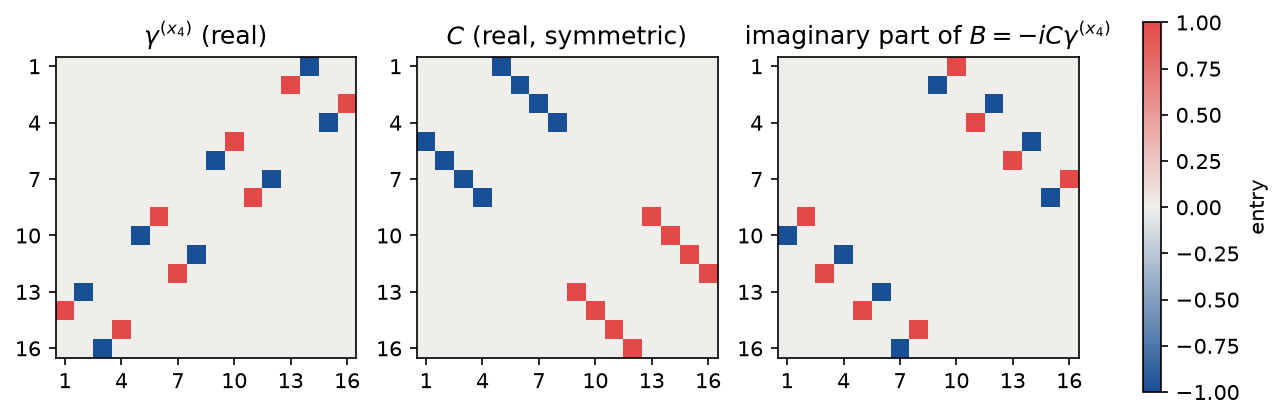

Figure 10a.1 saved as Revision/textbook/figures/10a_1_gamma4_c_and_b.png


In [4]:
from matplotlib.colors import LinearSegmentedColormap  # colour scales

BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
# A diverging colour scale: dark blue (negative), light grey (zero), red (positive).
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_grey_red", ["#184f95", "#f0efec", "#e34948"])
# A sequential colour scale for sizes: almost white (zero) to dark blue (large).
SEQUENTIAL = LinearSegmentedColormap.from_list(
    "white_blue", ["#fcfcfb", "#86b6ef", "#184f95"])


def draw_matrix(ax, matrix, title, cmap=DIVERGING, vmin=-1.0, vmax=1.0):
    """Draw a real matrix as a heat map with rows and columns numbered from 1."""
    image = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    size = matrix.shape[0]
    ticks = list(range(0, size, 3))  # every third row and column is labelled
    ax.set_xticks(ticks, [str(t + 1) for t in ticks])
    ax.set_yticks(ticks, [str(t + 1) for t in ticks])
    ax.grid(False)  # no grid lines on top of the squares
    ax.set_title(title)
    return image


fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
draw_matrix(axes[0], gamma[4], "$\\gamma^{(x_4)}$ (real)")
draw_matrix(axes[1], C, "$C$ (real, symmetric)")
image = draw_matrix(axes[2], B.imag, "imaginary part of $B = -iC\\gamma^{(x_4)}$")
fig.colorbar(image, ax=list(axes), shrink=0.8, label="entry")
save_figure(fig, "gamma4_c_and_b",
            "Heat maps of three 16 by 16 matrices: the time gamma $\\gamma^{(x_4)}$ "
            "(left), the matrix $C = \\gamma^{(x_8)}\\gamma^{(x_1)}\\gamma^{(x_2)}"
            "\\gamma^{(x_3)}$ (middle) and the imaginary part of $B = -iC"
            "\\gamma^{(x_4)}$ (right; its real part is zero). Horizontal axis: "
            "column number, vertical axis: row number; red is $+1$, blue is $-1$, "
            "light grey is 0. Each row and each column has exactly one nonzero "
            "entry: all three are signed permutation matrices, so $B$ is $i$ times "
            "a real signed permutation. $\\gamma^{(x_4)}$ is antisymmetric, $C$ "
            "and the imaginary part of $B$ are symmetric about the diagonal.")

## 6. The mode Hamiltonian and its square

The next cell defines two functions. `mode_hamiltonian(m, k)` returns the numpy
matrix $h = -im\gamma^{(x_4)} - \gamma^{(x_4)}\sum_a k_a\gamma^{(x_a)}$, where `k` is a
dictionary that gives the momentum $k_a$ for some of the slice directions
$a = 1, 2, 3, 5, 6, 7, 8$ (missing directions have momentum 0).
`frequency_squared(m, k)` returns $w^2 = m^2 + \sum_a \eta_{aa}k_a^2$: the
space-like momenta enter with $+$, the extra-time momenta with $-$.

In [5]:
def mode_hamiltonian(m, k):
    """h = -i m gamma^(x4) - gamma^(x4) sum_a k_a gamma^(x_a), a numpy matrix;
    k is a dictionary {a: k_a} for some of the directions a = 1, 2, 3, 5, 6, 7, 8."""
    h = -1j * m * gamma[4]
    for a, k_a in k.items():
        h = h - k_a * (gamma[4] @ gamma[a])
    return h


def frequency_squared(m, k):
    """w^2 = m^2 + k1^2 + k2^2 + k3^2 + k8^2 - k5^2 - k6^2 - k7^2."""
    return m ** 2 + sum(eta[a] * k_a ** 2 for a, k_a in k.items())


example = {1: 0.3, 2: -1.1, 3: 0.7, 5: 0.4, 6: 0.2, 7: -0.9, 8: 1.3}  # any numbers
h_example = mode_hamiltonian(1.7, example)
w2_example = frequency_squared(1.7, example)
report("w^2 for m = 1.7 and the example momenta", f"{w2_example:.6f}")
error = np.max(np.abs(h_example @ h_example - w2_example * np.eye(16)))
report("largest entry of h^2 - w^2 I (rounding only)", f"{error:.1e}")
check(error < 1e-12, "numerical example: h^2 = w^2 I at one generic point")

RESULT w^2 for m = 1.7 and the example momenta = 5.360000
RESULT largest entry of h^2 - w^2 I (rounding only) = 8.9e-16
PASS numerical example: h^2 = w^2 I at one generic point


A numerical example is not a proof. The next cell repeats the computation EXACTLY
with sympy, for symbols $m, k_1, k_2, k_3, k_5, k_6, k_7, k_8$ that stand for any
real numbers. It checks two identities for all values at once:

- $h^2 = w^2 I_{16}$ (so every eigenvalue of $h$ is $+w$ or $-w$);
- $B h = h^\dagger B$ (so the Krein form $u^\dagger B u$ of every wave is conserved,
  as Section 4 showed).

Why $h^2 = w^2 I$ holds: $(-im\gamma^{(x_4)})^2 = -m^2(\gamma^{(x_4)})^2 = m^2$;
$(\gamma^{(x_4)}\gamma^{(x_a)})^2 = -(\gamma^{(x_4)})^2(\gamma^{(x_a)})^2 = \eta_{aa}$
for $a \neq 4$ (move the second $\gamma^{(x_4)}$ to the left past $\gamma^{(x_a)}$,
which costs a sign); and all mixed terms cancel in pairs because the matrices
$\gamma^{(x_4)}$ and $\gamma^{(x_4)}\gamma^{(x_a)}$ anticommute with each other.

In [6]:
g = {a: sp.Matrix(fixture["gamma"][a - 1]) for a in range(1, 9)}  # exact gammas
C_exact = g[8] * g[1] * g[2] * g[3]
B_exact = -sp.I * C_exact * g[4]
m = sp.Symbol("m", real=True)  # the mass: any real number
k_sym = {a: sp.Symbol(f"k{a}", real=True) for a in (1, 2, 3, 5, 6, 7, 8)}


def mode_hamiltonian_exact(mass, k):
    """The same h as mode_hamiltonian, as an exact sympy matrix."""
    h = -sp.I * mass * g[4]
    for a, k_a in k.items():
        h = h - k_a * g[4] * g[a]
    return h


zero = sp.zeros(16, 16)
h_sym = mode_hamiltonian_exact(m, k_sym)
w2_sym = m ** 2 + sum(eta[a] * k_sym[a] ** 2 for a in k_sym)
say(f"w^2 = {w2_sym}")
square_ok = (h_sym * h_sym - w2_sym * sp.eye(16)).applyfunc(sp.expand) == zero
check_record(square_ok, "exact: h^2 = w^2 I for all real m and k",
             record="Revision/pairing/reports/wolfram-pairing.json, check "
                    "Q_one_particle_flat_dispersion")
krein_ok = (B_exact * h_sym - h_sym.H * B_exact).applyfunc(sp.expand) == zero
check_record(krein_ok,
             "exact: B h = h^dagger B for all real m and k (Krein self-adjoint)",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "mode_hamiltonian_B_selfadjoint_dispersion")

w^2 = k1**2 + k2**2 + k3**2 - k5**2 - k6**2 - k7**2 + k8**2 + m**2
PASS exact: h^2 = w^2 I for all real m and k
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    Q_one_particle_flat_dispersion
PASS exact: B h = h^dagger B for all real m and k (Krein self-adjoint)
     reproduces Revision/theory/reports/python-field-theory.json, check
    mode_hamiltonian_B_selfadjoint_dispersion


When is $h$ Hermitian, and when does it commute with $B$? The next cell computes
the exact matrices $h - h^\dagger$ and $Bh - hB$ and lists the symbols that appear
in them. Only $k_5, k_6, k_7$ appear: both matrices vanish exactly when there is no
momentum along the extra times, the *good sector*. (The reason: $\gamma^{(x_4)}
\gamma^{(x_a)}$ is Hermitian for the space-like directions and anti-Hermitian for
the extra times, and it commutes with $B$ for $a = 1, 2, 3, 8$ and anticommutes
with $B$ for $a = 5, 6, 7$.)

In [7]:
not_hermitian_part = (h_sym - h_sym.H).applyfunc(sp.expand)
commutator = (B_exact * h_sym - h_sym * B_exact).applyfunc(sp.expand)
symbols_1 = sorted(str(s) for s in not_hermitian_part.free_symbols)
symbols_2 = sorted(str(s) for s in commutator.free_symbols)
say(f"symbols in h - h^dagger: {symbols_1}")
say(f"symbols in B h - h B:    {symbols_2}")
good_sector = {k_sym[5]: 0, k_sym[6]: 0, k_sym[7]: 0}  # no extra-time momentum
check_record(symbols_1 == ["k5", "k6", "k7"]
             and not_hermitian_part.subs(good_sector) == zero,
             "exact: h is Hermitian exactly in the good sector k5 = k6 = k7 = 0",
             record="Revision/theory/reports/wolfram-field-theory.json, check "
                    "mode_hamiltonian_good_sector")
check_record(symbols_2 == ["k5", "k6", "k7"]
             and commutator.subs(good_sector) == zero,
             "exact: B h = h B exactly in the good sector",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "good_sector_spectrum_and_B_sectors")

symbols in h - h^dagger: ['k5', 'k6', 'k7']
symbols in B h - h B:    ['k5', 'k6', 'k7']
PASS exact: h is Hermitian exactly in the good sector k5 = k6 = k7 = 0
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    mode_hamiltonian_good_sector
PASS exact: B h = h B exactly in the good sector
     reproduces Revision/theory/reports/python-field-theory.json, check
    good_sector_spectrum_and_B_sectors


## 7. The three cases: real, zero and imaginary frequency

Since $h^2 = w^2 I_{16}$, everything depends on the sign of
$w^2 = m^2 + k_s^2 - k_t^2$, where $k_s^2 = k_1^2 + k_2^2 + k_3^2 + k_8^2$ collects the
space-like momenta and $k_t^2 = k_5^2 + k_6^2 + k_7^2$ the extra-time momenta:

- $w^2 > 0$: the frequencies $\pm w$ are real and the wave oscillates;
- $w^2 = 0$: $h^2 = 0$ and the wave grows linearly in $x_4$;
- $w^2 < 0$: the frequencies are $\pm i\kappa$ with $\kappa = \sqrt{-w^2}$, and one
  half of the waves grows like $e^{\kappa x_4}$.

The next cell draws $w^2$ against $k_5$ (the only extra-time momentum here) for
$m = 1$ and three values of $k_s$, and checks that the zero crossing lies at
$k_5 = \sqrt{m^2 + k_s^2}$.

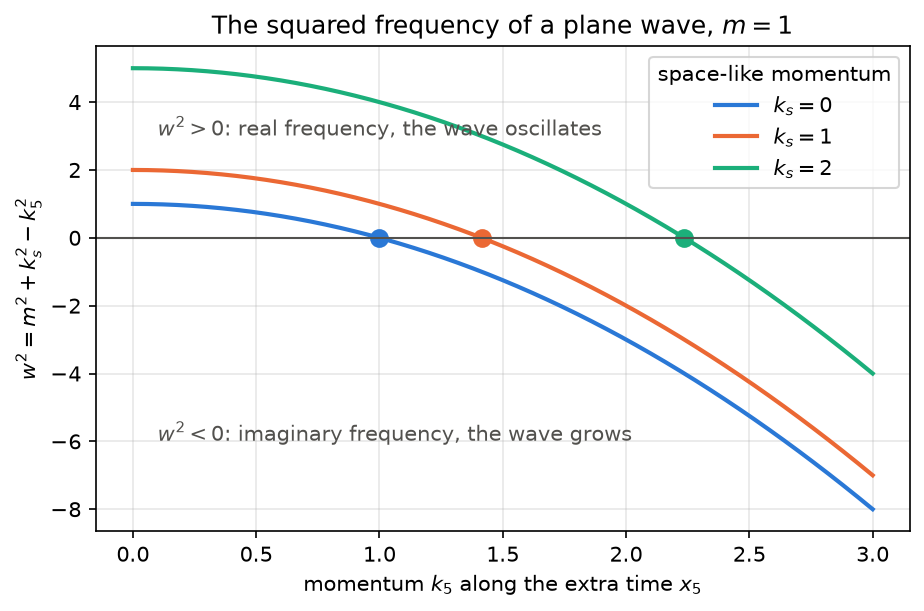

Figure 10a.2 saved as Revision/textbook/figures/10a_2_frequency_squared.png
PASS w^2 = 0 exactly at k5 = sqrt(m^2 + k_s^2)


In [8]:
k5_values = np.linspace(0.0, 3.0, 301)  # 301 values of k5 from 0 to 3
fig, ax = plt.subplots()
for k_s, colour in ((0.0, BLUE), (1.0, ORANGE), (2.0, GREEN)):
    w2_curve = [frequency_squared(1.0, {1: k_s, 5: k5}) for k5 in k5_values]
    ax.plot(k5_values, w2_curve, color=colour, linewidth=2,
            label=f"$k_s = {k_s:.0f}$")
    crossing = np.sqrt(1.0 + k_s ** 2)  # where w^2 = 0
    ax.plot([crossing], [0.0], "o", color=colour, markersize=8)
ax.axhline(0.0, color=GREY, linewidth=1)
ax.text(0.1, 3.0, "$w^2 > 0$: real frequency, the wave oscillates", color=GREY)
ax.text(0.1, -6.0, "$w^2 < 0$: imaginary frequency, the wave grows", color=GREY)
ax.set_xlabel("momentum $k_5$ along the extra time $x_5$")
ax.set_ylabel("$w^2 = m^2 + k_s^2 - k_5^2$")
ax.set_title("The squared frequency of a plane wave, $m = 1$")
ax.legend(title="space-like momentum")
save_figure(fig, "frequency_squared",
            "The squared frequency $w^2 = m^2 + k_s^2 - k_5^2$ of a plane wave with "
            "mass $m = 1$, plotted against the momentum $k_5$ along the extra time "
            "$x_5$ (horizontal axis, units of $m$) for the space-like momentum "
            "$k_s = 0$, 1 and 2 (the three curves). Vertical axis: $w^2$ in units "
            "of $m^2$. Above the grey line the frequency is real and the wave "
            "oscillates; below it the frequency is imaginary and the wave grows. "
            "The dots mark $k_5 = \\sqrt{m^2 + k_s^2}$, where the wave changes "
            "from oscillation to growth: a large enough extra-time momentum always "
            "wins.")
check(all(abs(frequency_squared(1.0, {1: k_s, 5: np.sqrt(1.0 + k_s ** 2)})) < 1e-12
          for k_s in (0.0, 1.0, 2.0)),
      "w^2 = 0 exactly at k5 = sqrt(m^2 + k_s^2)")

## 8. The eigenvalues as the extra-time momentum grows

The next cell computes the 16 eigenvalues of $h$ numerically (numpy's
`np.linalg.eigvals`) for $m = 1$, no space-like momentum, and $k_5$ from 0 to 3, and
plots their real and imaginary parts. The formula predicts eight eigenvalues
$+\sqrt{1 - k_5^2}$ and eight $-\sqrt{1 - k_5^2}$ for $k_5 < 1$, and eight $+i\kappa$
and eight $-i\kappa$ with $\kappa = \sqrt{k_5^2 - 1}$ for $k_5 > 1$. At $k_5 = 1$
exactly the matrix cannot be diagonalised and the numerical eigenvalues are only
accurate to about $10^{-8}$, so the check leaves out the points with
$|w^2| < 0.05$.

RESULT largest difference from the formula +-w (8 times each) = 3.6e-15
PASS the 16 eigenvalues of h are +w and -w, eight times each


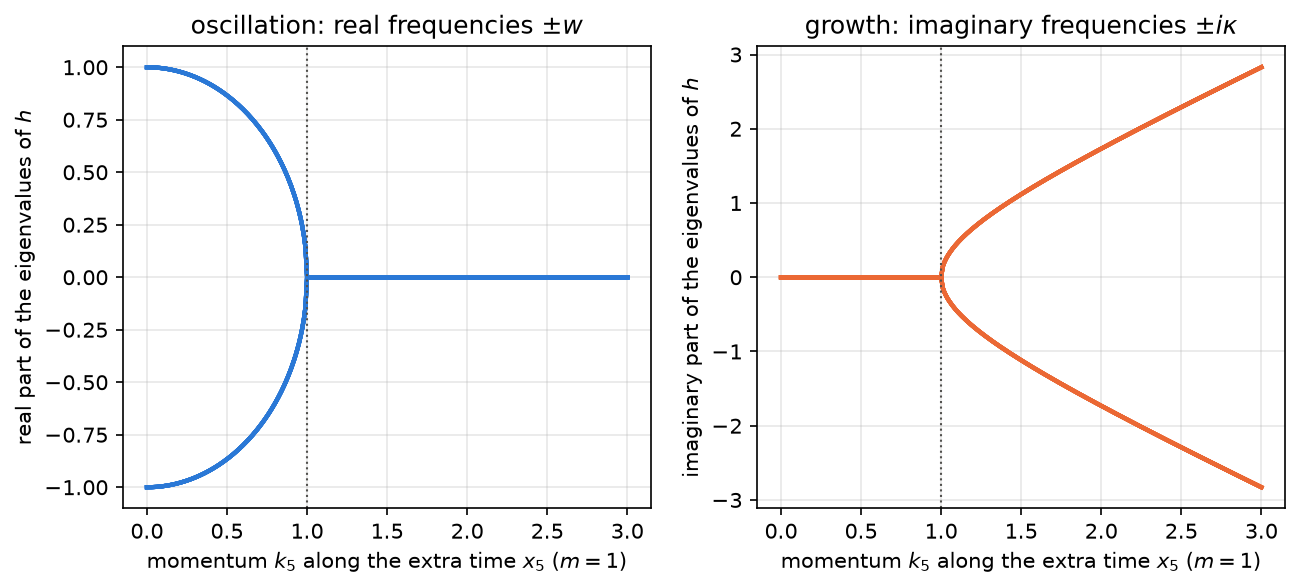

Figure 10a.3 saved as Revision/textbook/figures/10a_3_eigenvalue_flow.png


In [9]:
real_parts, imaginary_parts, worst = [], [], 0.0
for k5 in k5_values:
    eigenvalues = np.linalg.eigvals(mode_hamiltonian(1.0, {5: k5}))
    real_parts.append(np.sort(eigenvalues.real))
    imaginary_parts.append(np.sort(eigenvalues.imag))
    w2 = 1.0 - k5 ** 2
    if abs(w2) > 0.05:  # away from the point where h cannot be diagonalised
        w = np.sqrt(complex(w2))  # sqrt of a negative number is imaginary
        predicted = np.array([w] * 8 + [-w] * 8)
        # compare the sorted real parts and the sorted imaginary parts separately
        worst = max(worst,
                    np.max(np.abs(np.sort(eigenvalues.real) - np.sort(predicted.real))),
                    np.max(np.abs(np.sort(eigenvalues.imag) - np.sort(predicted.imag))))
report("largest difference from the formula +-w (8 times each)", f"{worst:.1e}")
check(worst < 1e-10, "the 16 eigenvalues of h are +w and -w, eight times each")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharex=True)
axes[0].plot(k5_values, np.array(real_parts), color=BLUE, linewidth=2)
axes[1].plot(k5_values, np.array(imaginary_parts), color=ORANGE, linewidth=2)
for ax, what in ((axes[0], "real part"), (axes[1], "imaginary part")):
    ax.axvline(1.0, color=GREY, linestyle=":", linewidth=1)
    ax.set_xlabel("momentum $k_5$ along the extra time $x_5$ ($m = 1$)")
    ax.set_ylabel(f"{what} of the eigenvalues of $h$")
axes[0].set_title("oscillation: real frequencies $\\pm w$")
axes[1].set_title("growth: imaginary frequencies $\\pm i\\kappa$")
save_figure(fig, "eigenvalue_flow",
            "The 16 eigenvalues of the mode Hamiltonian $h$ for mass $m = 1$ and "
            "only the extra-time momentum $k_5$ (horizontal axis, units of $m$): "
            "their real parts (left, blue) and imaginary parts (right, orange), "
            "vertical axes in units of $m$; each curve carries eight eigenvalues. "
            "For $k_5 < 1$ the eigenvalues are the real numbers $\\pm\\sqrt{1 - "
            "k_5^2}$, which move together and meet at 0 at $k_5 = 1$ (dotted line); "
            "for $k_5 > 1$ they leave the real axis as $\\pm i\\sqrt{k_5^2 - 1}$, "
            "and the waves with $+i\\kappa$ grow like $e^{\\kappa x_4}$.")

## 9. Krein inertia of the eigenspaces: the recorded samples

The next cell defines three functions.

- `orthonormal_basis(P)` returns an orthonormal basis of the range of a matrix $P$
  by the Gram-Schmidt method: take the columns of $P$ in order, remove from each
  its parts along the basis vectors found so far, and keep it (divided by its
  length) if something is left. The procedure is repeated once to remove rounding
  errors.
- `eigenspace(m, k, sign)` returns such a basis of the eigenspace of $+w$
  (`sign = +1`) or $-w$ (`sign = -1`), as the range of the projector
  $P_\pm = \frac12(I \pm h/w)$ of Section 4. For $w^2 < 0$ the number $w$ is
  $i\kappa$, and the same formula gives the eigenspaces of $\pm i\kappa$.
- `krein_inertia(V)` computes the Gram matrix $G = V^\dagger B V$ (entry $(i, j)$ is
  the Krein form of the basis vectors $i$ and $j$) and counts its positive,
  negative and zero eigenvalues (zero means smaller than $10^{-8}$). It also returns
  the smallest size of a nonzero eigenvalue, to show that no eigenvalue is close
  to the borderline $10^{-8}$.

In [10]:
def orthonormal_basis(P):
    """Orthonormal columns that span the range of P (Gram-Schmidt, done twice)."""
    basis = []
    for column in P.T:  # the columns of P, in order
        v = column.astype(complex)
        for _ in range(2):  # the second pass removes rounding errors
            for e in basis:
                v = v - (e.conj() @ v) * e  # remove the part of v along e
        length = np.sqrt((v.conj() @ v).real)
        if length > 1e-8:  # v is not a combination of the earlier columns
            basis.append(v / length)
    return np.array(basis).T  # the basis vectors as the columns of a matrix


def eigenspace(m, k, sign):
    """Orthonormal basis of the eigenspace of h for the eigenvalue sign * w."""
    h = mode_hamiltonian(m, k)
    w = np.sqrt(complex(frequency_squared(m, k)))  # w, or i kappa when w^2 < 0
    P = (np.eye(16) + sign * h / w) / 2  # the projector P_+ or P_-
    return orthonormal_basis(P)


def krein_inertia(V):
    """(positive, negative, zero) eigenvalues of V^dagger B V, and the smallest
    size of a nonzero one (None when all are zero)."""
    G = V.conj().T @ B @ V  # the Krein form on the span of the columns of V
    values = np.linalg.eigvalsh(G)
    nonzero = np.abs(values[np.abs(values) > 1e-8])
    counts = (int(np.sum(values > 1e-8)), int(np.sum(values < -1e-8)),
              int(np.sum(np.abs(values) <= 1e-8)))
    return counts, (float(nonzero.min()) if nonzero.size else None)

The Revision pairing record `Revision/pairing/pairing-theory.json` stores eight
samples (entry `data`, `one_particle_flat`, `samples`): for each a mass $m$, a
momentum list $(k_1, \dots, k_8)$ (the entry $k_4$ is not used), the frequency $w$
(written in the notation of the Wolfram Language, for example `Sqrt[2]`), the
dimensions of the two eigenspaces and their Krein inertia. The next cell reads them,
recomputes every number, prints one line per sample and checks that everything
agrees.

In [11]:
pairing = json.loads(repository_file("Revision/pairing/pairing-theory.json")
                     .read_text(encoding="utf-8"))
samples = pairing["data"]["one_particle_flat"]["samples"]
all_agree = True
say("   m  nonzero momenta         w      dims   inertia(+w)  inertia(-w)")
for sample in samples:
    m_value, k_list = sample["m"], sample["k"]
    k = {a: k_list[a - 1] for a in (1, 2, 3, 5, 6, 7, 8) if k_list[a - 1] != 0}
    # "Sqrt[2]" (Wolfram notation) -> the number sqrt(2)
    w_recorded = float(sp.sympify(sample["w"].replace("Sqrt[", "sqrt(")
                                  .replace("]", ")")))
    w = np.sqrt(frequency_squared(m_value, k))
    found = []
    for sign in (+1, -1):
        V = eigenspace(m_value, k, sign)
        counts, _ = krein_inertia(V)
        found.append((V.shape[1], counts))
    agree = (abs(w - w_recorded) < 1e-12
             and found[0][0] == sample["dim_plus_w"]
             and found[1][0] == sample["dim_minus_w"]
             and list(found[0][1][:2]) == sample["B_inertia_plus_w"]
             and list(found[1][1][:2]) == sample["B_inertia_minus_w"]
             and found[0][1][2] == 0 and found[1][1][2] == 0)
    all_agree = all_agree and agree
    momenta = ", ".join(f"k{a}={v}" for a, v in k.items()) or "none"
    say(f"{m_value:4d}  {momenta:22s} {w:7.4f}   {found[0][0]},{found[1][0]}    "
        f"{found[0][1][:2]}       {found[1][1][:2]}")
check_record(all_agree,
             "all 8 recorded samples: w, dimensions 8 and 8, Krein inertia (4, 4)",
             record="Revision/pairing/pairing-theory.json, data one_particle_flat")

   m  nonzero momenta         w      dims   inertia(+w)  inertia(-w)
   2  k1=1, k2=2, k8=4        5.0000   8,8    (4, 4)       (4, 4)
  -2  k1=1, k2=2, k8=4        5.0000   8,8    (4, 4)       (4, 4)
   3  none                    3.0000   8,8    (4, 4)       (4, 4)
  -3  none                    3.0000   8,8    (4, 4)       (4, 4)
   1  k1=1                    1.4142   8,8    (4, 4)       (4, 4)
  -1  k1=1                    1.4142   8,8    (4, 4)       (4, 4)
   2  k5=1                    1.7321   8,8    (4, 4)       (4, 4)
  -2  k5=1                    1.7321   8,8    (4, 4)       (4, 4)
PASS all 8 recorded samples: w, dimensions 8 and 8, Krein inertia (4, 4)
     reproduces Revision/pairing/pairing-theory.json, data one_particle_flat


Two more recorded statements. The sympy pairing verifier uses the sample $m = 1$,
$k_1 = 2$, $k_8 = 2$ (so $w = \sqrt{1 + 4 + 4} = 3$). Its imaginary-frequency samples
are $m = 1$ with $k_5 = 2$ ($w^2 = -3$) and with $k_1 = 1$, $k_5 = 2$ ($w^2 = -2$):
there both eigenspaces must be *neutral*, inertia $(0, 0, 8)$. For $m = 1$, $k_5 = 1$
the frequency is zero: $h^2 = 0$, the range of $h$ has dimension 8, and since
$(hx)^\dagger B (hy) = x^\dagger h^\dagger B h y = x^\dagger B h^2 y = 0$, the range of
$h$ is neutral as well. The next cell checks all of this.

In [12]:
sample_3 = {1: 2, 8: 2}
inertias_3 = [krein_inertia(eigenspace(1, sample_3, s))[0] for s in (+1, -1)]
report("w for m = 1, k1 = 2, k8 = 2", f"{np.sqrt(frequency_squared(1, sample_3)):.6f}")
say(f"inertia of the +w and -w eigenspaces: {inertias_3}")
check_record(inertias_3 == [(4, 4, 0), (4, 4, 0)],
             "m = 1, k1 = 2, k8 = 2 (w = 3): inertia (4, 4) on both eigenspaces",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.one_particle_Krein_inertia")
neutral_ok = True
for k in ({5: 2}, {1: 1, 5: 2}):
    spaces = [eigenspace(1, k, s) for s in (+1, -1)]
    inertias = [krein_inertia(V)[0] for V in spaces]
    say(f"m = 1, momenta {k}: w^2 = {frequency_squared(1, k)}, dimensions "
        f"{[V.shape[1] for V in spaces]}, inertia {inertias}")
    neutral_ok = neutral_ok and inertias == [(0, 0, 8), (0, 0, 8)]
h_zero = mode_hamiltonian(1, {5: 1})  # w^2 = 1 - 1 = 0
rank_h = int(np.linalg.matrix_rank(h_zero))
nilpotent = np.max(np.abs(h_zero @ h_zero)) < 1e-12  # h^2 = 0
range_neutral = np.max(np.abs(h_zero.conj().T @ B @ h_zero)) < 1e-12
say(f"m = 1, k5 = 1: w^2 = 0, h^2 = 0: {nilpotent}, rank of h = {rank_h}, "
    f"range of h neutral: {range_neutral}")
check_record(neutral_ok and nilpotent and rank_h == 8 and range_neutral,
             "imaginary and zero frequencies: the eigenspaces are Krein-neutral",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.one_particle_complex_frequency_Krein_neutral")

RESULT w for m = 1, k1 = 2, k8 = 2 = 3.000000
inertia of the +w and -w eigenspaces: [(4, 4, 0), (4, 4, 0)]
PASS m = 1, k1 = 2, k8 = 2 (w = 3): inertia (4, 4) on both eigenspaces
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_Krein_inertia
m = 1, momenta {5: 2}: w^2 = -3, dimensions [8, 8], inertia [(0, 0, 8), (0, 0, 8)]
m = 1, momenta {1: 1, 5: 2}: w^2 = -2, dimensions [8, 8], inertia [(0, 0, 8), (0, 0, 8)]
m = 1, k5 = 1: w^2 = 0, h^2 = 0: True, rank of h = 8, range of h neutral: True
PASS imaginary and zero frequencies: the eigenspaces are Krein-neutral
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_complex_frequency_Krein_neutral


## 10. Why the inertia is (4, 4) at EVERY real frequency

Samples are not a proof. The Revision record proves the statement for every real
frequency in three steps, which the next cells repeat.

**Step (i).** For real $w > 0$: $P_+^\dagger B P_- = 0$ and $P_+^\dagger B P_+ =
BP_+$. Line by line, with $P_\pm = \frac12(I \pm h/w)$ and $P_+^\dagger = \frac12(I +
h^\dagger/w)$ ($w$ is real):

$$4w^2\,P_+^\dagger B P_- = (wI + h^\dagger)B(wI - h) = w^2 B - wBh + wh^\dagger B -
h^\dagger B h .$$

Use $h^\dagger B = Bh$ twice: the two middle terms cancel, and $h^\dagger B h = B h h
= w^2 B$, so the right-hand side is $w^2B - w^2B = 0$. Hence the two eigenspaces
are Krein-orthogonal: a wave of frequency $+w$ and one of $-w$ have zero mixed
Krein form. Since $B$ is invertible and the two eigenspaces together span all 16
directions, $B$ cannot vanish on either of them (it is *nondegenerate* on each).

**Step (ii).** In the good sector $Bh = hB$, so $\mathrm{tr}(BP_\pm) = \frac12
\mathrm{tr}B \pm \frac{1}{2w}\mathrm{tr}(Bh)$, and both traces are 0. The trace of
$BP_+$ is the sum of the eigenvalues of $B$ on the $+w$ eigenspace (in the good
sector $B$ maps this eigenspace into itself), each $+1$ or $-1$; a sum of eight
such numbers is 0 only with four of each: inertia $(4, 4)$.

**Step (iii).** Turning on the extra-time momenta slowly at fixed $m, k_1, k_2, k_3,
k_8$ keeps $w^2$ positive as long as $k_t^2 < m^2 + k_s^2$, the projectors change
continuously, and the Krein form stays nondegenerate on their ranges by step (i).
An eigenvalue of the Gram matrix could change sign only by passing through 0, which
nondegeneracy forbids: the inertia stays $(4, 4)$ at every real frequency.

The next cell checks the identities of steps (i) and (ii) exactly with sympy. The
letter $w$ is a positive symbol, and after expanding, every $w^2$ is replaced by
$m^2 + k_s^2 - k_t^2$.

In [13]:
w = sp.Symbol("w", positive=True)
I16 = sp.eye(16)


def replace_w_squared(matrix):
    """Expand every entry and replace w^2 by m^2 + k_s^2 - k_t^2."""
    return matrix.applyfunc(lambda e: sp.expand(sp.expand(e).subs(w ** 2, w2_sym)))


step_i_a = replace_w_squared((w * I16 + h_sym.H) * B_exact * (w * I16 - h_sym))
step_i_b = replace_w_squared((w * I16 + h_sym.H) * B_exact * (w * I16 + h_sym)
                             - 2 * w * B_exact * (w * I16 + h_sym))
check_record(step_i_a == zero and step_i_b == zero,
             "exact step (i): 4 w^2 P+^dagger B P- = 0 and P+^dagger B P+ = B P+",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.one_particle_Krein_inertia_proof")
trace_B_h = sp.expand((B_exact * h_sym).trace())
say(f"exact: tr B = {B_exact.trace()}, tr(B h) = {trace_B_h}")
check(B_exact.trace() == 0 and trace_B_h == 0,
      "exact step (ii): tr B = tr(B h) = 0, so tr(B P+) = tr(B P-) = 0")

PASS exact step (i): 4 w^2 P+^dagger B P- = 0 and P+^dagger B P+ = B P+
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_Krein_inertia_proof
exact: tr B = 0, tr(B h) = 0
PASS exact step (ii): tr B = tr(B h) = 0, so tr(B P+) = tr(B P-) = 0


Step (iii) is a statement about continuity. The next cell shows it at work: for
$m = 1$, the space-like momentum $k_1 = 0.5$ and the extra-time momentum $k_5$ from 0
to 2.5 it computes the Krein inertia of the $+w$ eigenspace. The threshold is
$k_5 = \sqrt{1.25} \approx 1.118$; points closer than 0.02 to it are skipped (there
the eigenspaces merge). Below the threshold the inertia must be $(4, 4, 0)$ at every
point, above it $(0, 0, 8)$. The cell also records the smallest size of a nonzero
eigenvalue of the Gram matrix: it shrinks towards the threshold but never reaches 0
before it.

RESULT points below and above the threshold = 110 and 137
RESULT smallest nonzero Gram eigenvalue below the threshold = 0.2225
PASS scan: inertia (4, 4) at every real frequency, (0, 0, 8) at every imaginary one


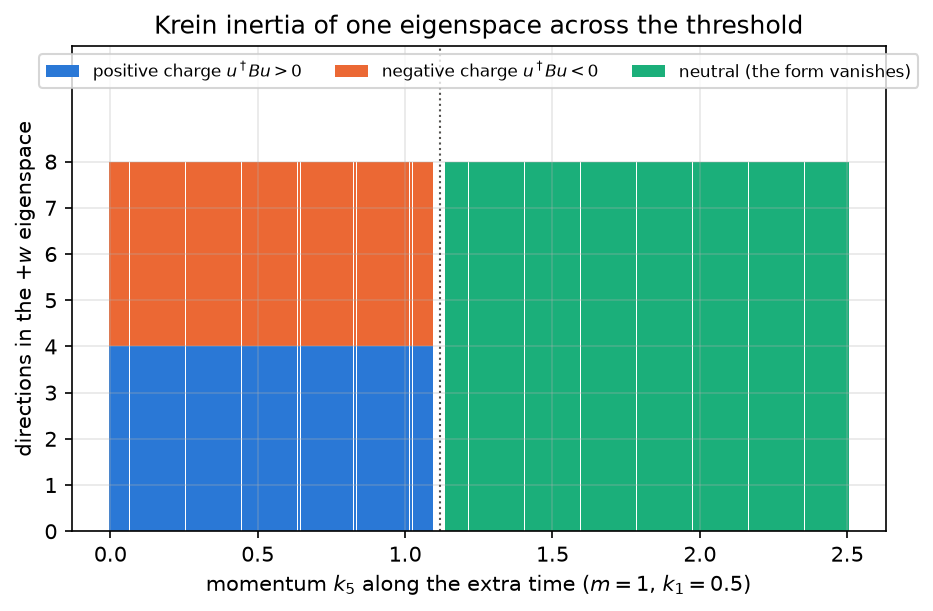

Figure 10a.4 saved as Revision/textbook/figures/10a_4_krein_inertia_scan.png


In [14]:
threshold = np.sqrt(1.25)
scan = [k5 for k5 in np.linspace(0.0, 2.5, 251) if abs(k5 - threshold) > 0.02]
counts_scan, margins = [], []
for k5 in scan:
    counts, margin = krein_inertia(eigenspace(1.0, {1: 0.5, 5: k5}, +1))
    counts_scan.append(counts)
    if margin is not None:
        margins.append(margin)
below = [c for k5, c in zip(scan, counts_scan) if k5 < threshold]
above = [c for k5, c in zip(scan, counts_scan) if k5 > threshold]
report("points below and above the threshold", f"{len(below)} and {len(above)}")
report("smallest nonzero Gram eigenvalue below the threshold", f"{min(margins):.4f}")
check(set(below) == {(4, 4, 0)} and set(above) == {(0, 0, 8)},
      "scan: inertia (4, 4) at every real frequency, (0, 0, 8) at every imaginary "
      "one")

counts_array = np.array(counts_scan)  # one row (positive, negative, zero) per k5
fig, ax = plt.subplots()
width = 0.0098  # each bar is as wide as the step 0.01 between the k5 values
# Stacked bars: the blue part (positive directions) starts at 0, the orange part
# (negative directions) on top of it, the green part (neutral) on top of both.
ax.bar(scan, counts_array[:, 0], width=width, color=BLUE,
       label="positive charge $u^\\dagger B u > 0$")
ax.bar(scan, counts_array[:, 1], width=width, bottom=counts_array[:, 0],
       color=ORANGE, label="negative charge $u^\\dagger B u < 0$")
ax.bar(scan, counts_array[:, 2], width=width,
       bottom=counts_array[:, 0] + counts_array[:, 1], color=GREEN,
       label="neutral (the form vanishes)")
ax.axvline(threshold, color=GREY, linestyle=":", linewidth=1)
ax.set_xlabel("momentum $k_5$ along the extra time ($m = 1$, $k_1 = 0.5$)")
ax.set_ylabel("directions in the $+w$ eigenspace")
ax.set_yticks(range(0, 9))
ax.set_ylim(0.0, 10.5)  # room for the legend above the bars
ax.set_title("Krein inertia of one eigenspace across the threshold")
ax.legend(loc="upper center", ncol=3, fontsize=8)
save_figure(fig, "krein_inertia_scan",
            "The Krein inertia of the eigenspace of $+w$ of the mode Hamiltonian "
            "for $m = 1$, $k_1 = 0.5$ and the extra-time momentum $k_5$ from 0 to "
            "2.5 (horizontal axis, units of $m$). Each thin bar splits the eight "
            "independent directions of the eigenspace (vertical axis) into those "
            "of positive charge (blue), negative charge (orange) and zero charge "
            "for every pair (green). Left of the threshold $k_5 = \\sqrt{1.25}$ "
            "(dotted line) the frequency is real and the split is always 4 and 4; "
            "right of it the frequency is imaginary and the whole eigenspace is "
            "neutral: the growing waves carry no charge.")

## 11. Three pictures of the Krein form on the eigenvectors

The next cell puts the 8 basis vectors of the $+w$ eigenspace and the 8 of the $-w$
eigenspace side by side as the 16 columns of a matrix $W$, and draws the sizes of the
entries of the Gram matrix $W^\dagger B W$ for three waves:

- the good-sector sample $m = 2$, $k = (1, 2, 0, 4)$ along $(x_1, x_2, x_3, x_8)$,
  $w = 5$;
- $m = 2$ with the extra-time momentum $k_5 = 1$: still a real frequency,
  $w = \sqrt3$;
- $m = 1$, $k_5 = 2$: an imaginary frequency, $w = i\sqrt3$.

In the first two pictures only the two diagonal $8 \times 8$ blocks are nonzero
(the eigenspaces are Krein-orthogonal, step (i)); in the third the diagonal blocks
vanish (each eigenspace is neutral) and only the off-diagonal blocks remain: a
growing wave has nonzero Krein form only with a decaying one.

case 1: largest entry in the diagonal blocks 0.894; off-diagonal blocks below 1e-12: True
case 2: largest entry in the diagonal blocks 0.866; off-diagonal blocks below 1e-12: True
case 3: largest entry in the diagonal blocks 0.000; off-diagonal blocks below 1e-12:
    False


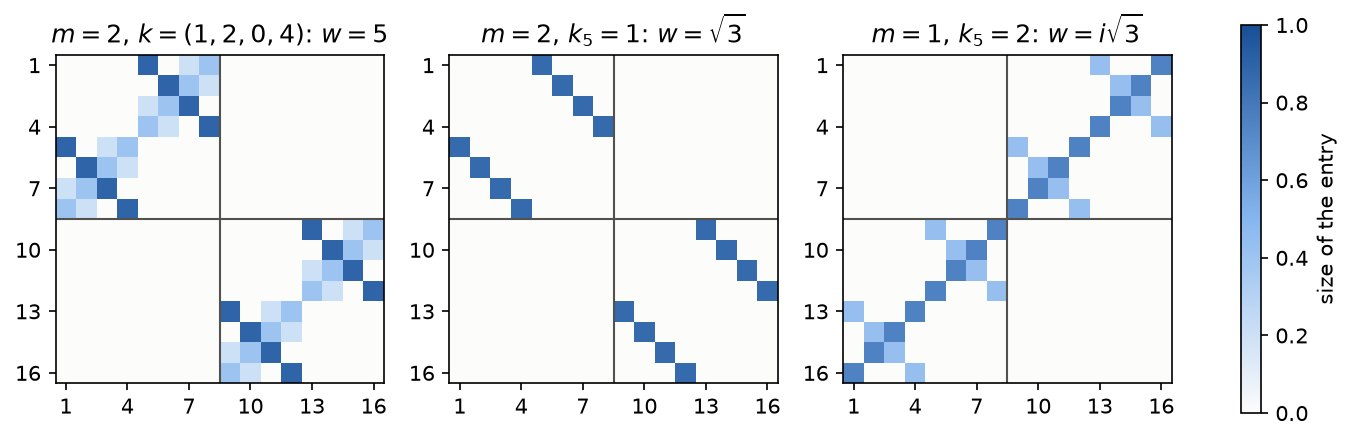

Figure 10a.5 saved as Revision/textbook/figures/10a_5_krein_gram_matrices.png
PASS real w: the eigenspaces are Krein-orthogonal; imaginary w: each is neutral


In [15]:
cases = [(2, {1: 1, 2: 2, 8: 4}, "$m = 2$, $k = (1, 2, 0, 4)$: $w = 5$"),
         (2, {5: 1}, "$m = 2$, $k_5 = 1$: $w = \\sqrt{3}$"),
         (1, {5: 2}, "$m = 1$, $k_5 = 2$: $w = i\\sqrt{3}$")]
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.2))
block_sizes = []
for ax, (m_value, k, title) in zip(axes, cases):
    W = np.hstack([eigenspace(m_value, k, +1), eigenspace(m_value, k, -1)])
    gram = np.abs(W.conj().T @ B @ W)  # sizes of the Krein form between columns
    image = draw_matrix(ax, gram, title, cmap=SEQUENTIAL, vmin=0.0, vmax=1.0)
    ax.axhline(7.5, color=GREY, linewidth=1)  # the border between the two
    ax.axvline(7.5, color=GREY, linewidth=1)  # eigenspaces (rows/columns 8 and 9)
    diagonal_blocks = max(gram[:8, :8].max(), gram[8:, 8:].max())
    off_blocks = max(gram[:8, 8:].max(), gram[8:, :8].max())
    block_sizes.append((diagonal_blocks, off_blocks))
    say(f"case {len(block_sizes)}: largest entry in the diagonal blocks "
        f"{diagonal_blocks:.3f}; off-diagonal blocks below 1e-12: {off_blocks < 1e-12}")
fig.colorbar(image, ax=list(axes), shrink=0.8, label="size of the entry")
save_figure(fig, "krein_gram_matrices",
            "Sizes of the entries of the Gram matrix $W^\\dagger B W$, where the "
            "first 8 columns of $W$ span the eigenspace of $+w$ and the last 8 that "
            "of $-w$ (horizontal and vertical axes: column and row number; white is "
            "0, dark blue is 1; grey lines separate the two eigenspaces). Left: a "
            "good-sector wave with $w = 5$; middle: a wave with extra-time momentum "
            "and real $w = \\sqrt{3}$; right: a wave with imaginary $w = "
            "i\\sqrt{3}$. For real frequencies only the diagonal blocks are filled: "
            "the two eigenspaces are Krein-orthogonal. For the imaginary frequency "
            "the diagonal blocks are empty: each eigenspace is neutral.")
check(block_sizes[0][1] < 1e-12 and block_sizes[1][1] < 1e-12
      and block_sizes[2][0] < 1e-12 and block_sizes[2][1] > 0.1,
      "real w: the eigenspaces are Krein-orthogonal; imaginary w: each is neutral")

## 12. The universes of masses $+m$ and $-m$

The pairing theorem T1 of the Revision record relates the field of mass $m$ to the
field of mass $-m$ through the chirality matrix $\Gamma$. At the one-particle level
the record proves (statement Q4 of the quantum reading):

- $\Gamma h_m(k)\Gamma = h_{-m}(k)$, because $\Gamma$ anticommutes with
  $\gamma^{(x_4)}$ and commutes with every product $\gamma^{(x_4)}\gamma^{(x_a)}$;
- $\gamma^{(x_8)} h_m(k)\gamma^{(x_8)} = h_{-m}(R_8 k)$, where $R_8$ reverses the
  hidden momentum $k_8$.

Since $\Gamma^2 = I$ and $(\gamma^{(x_8)})^2 = I$, these are *similarity*
transformations: $h_{-m}$ has exactly the eigenvalues of $h_m$. The one-particle
spectra of the two universes are IDENTICAL, not opposite. The next cell checks both
identities exactly.

In [16]:
Gamma_exact = g[8] * g[1] * g[2] * g[3] * g[4] * g[5] * g[6] * g[7]
h_minus = mode_hamiltonian_exact(-m, k_sym)  # the same momenta, mass -m
k_reflected = dict(k_sym)
k_reflected[8] = -k_sym[8]  # R_8: k8 -> -k8
h_minus_reflected = mode_hamiltonian_exact(-m, k_reflected)
chirality_ok = (Gamma_exact * h_sym * Gamma_exact - h_minus).applyfunc(
    sp.expand) == zero
mirror_ok = (g[8] * h_sym * g[8] - h_minus_reflected).applyfunc(sp.expand) == zero
check_record(Gamma_exact * Gamma_exact == I16 and chirality_ok,
             "exact: Gamma h_m(k) Gamma = h_-m(k)",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.one_particle_maps")
check_record(mirror_ok, "exact: gamma^(x8) h_m(k) gamma^(x8) = h_-m(R_8 k)",
             record="Revision/pairing/reports/wolfram-pairing.json, check "
                    "Q_one_particle_maps")

PASS exact: Gamma h_m(k) Gamma = h_-m(k)
     reproduces Revision/pairing/reports/python-pairing.json, check Q.one_particle_maps
PASS exact: gamma^(x8) h_m(k) gamma^(x8) = h_-m(R_8 k)
     reproduces Revision/pairing/reports/wolfram-pairing.json, check Q_one_particle_maps


The Revision theory record also states how the good-sector spectrum splits between
the two eigenspaces of $B$. In the good sector $B$ commutes with $h$, so the
projector $P_B = \frac12(I + B)$ onto the eigenvalue $+1$ of $B$ (8 directions)
commutes with $h$, and $h$ acts inside that 8-dimensional space. For the exact
example $m = 2$, $k = (1, 2, 0, 4)$, $w = 5$, the matrix $P_B h P_B$ must have the
eigenvalue $+5$ four times, $-5$ four times and $0$ eight times (the 0 belongs to the
other 8 directions, which $P_B$ removes). The next cell checks this and then draws
the spectra of $h_m$ and $h_{-m}$ for $m = 2$ against $k_1$ and, at fixed $k_1 = 1$,
against $m$ from $-3$ to $3$.

eigenvalues of P_B h P_B and how often each occurs: {5.0: 4, -5.0: 4, 0.0: 8}
PASS good sector, m = 2, k = (1, 2, 0, 4): on B = +1 energies +5, -5 (4 each)
     reproduces Revision/theory/reports/python-field-theory.json, check
    good_sector_spectrum_and_B_sectors
RESULT largest difference between the spectra of m = 2 and m = -2 = 0.0e+00
PASS numerical: the spectra of h_m and h_-m coincide


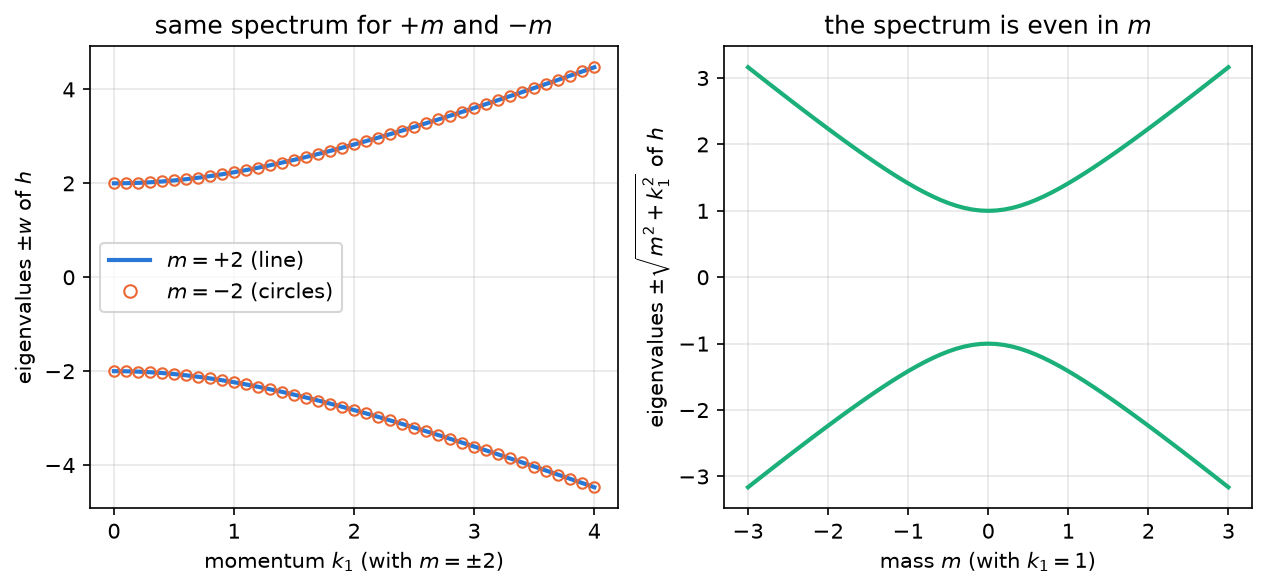

Figure 10a.6 saved as Revision/textbook/figures/10a_6_plus_minus_mass_spectra.png


In [17]:
h_sample = mode_hamiltonian(2, {1: 1, 2: 2, 8: 4})
P_B = (np.eye(16) + B) / 2  # projector onto the eigenvalue +1 of B
sector_values = np.round(np.linalg.eigvals(P_B @ h_sample @ P_B).real, 10)
multiplicities = {v: int(np.sum(sector_values == v)) for v in (5.0, -5.0, 0.0)}
say(f"eigenvalues of P_B h P_B and how often each occurs: {multiplicities}")
check_record(multiplicities == {5.0: 4, -5.0: 4, 0.0: 8},
             "good sector, m = 2, k = (1, 2, 0, 4): on B = +1 energies +5, -5 (4 each)",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "good_sector_spectrum_and_B_sectors")

k1_values = np.linspace(0.0, 4.0, 41)
plus_spectra = [np.sort(np.linalg.eigvals(mode_hamiltonian(2.0, {1: x})).real)
                for x in k1_values]
minus_spectra = [np.sort(np.linalg.eigvals(mode_hamiltonian(-2.0, {1: x})).real)
                 for x in k1_values]
mass_values = np.linspace(-3.0, 3.0, 61)
mass_spectra = [np.sort(np.linalg.eigvals(mode_hamiltonian(x, {1: 1.0})).real)
                for x in mass_values]
difference = np.max(np.abs(np.array(plus_spectra) - np.array(minus_spectra)))
report("largest difference between the spectra of m = 2 and m = -2", f"{difference:.1e}")
check(difference < 1e-10, "numerical: the spectra of h_m and h_-m coincide")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0))
axes[0].plot(k1_values, np.array(plus_spectra)[:, [0, 15]], color=BLUE, linewidth=2)
axes[0].plot(k1_values, np.array(minus_spectra)[:, [0, 15]], "o", color=ORANGE,
             markersize=5, fillstyle="none")
axes[0].plot([], [], color=BLUE, linewidth=2, label="$m = +2$ (line)")
axes[0].plot([], [], "o", color=ORANGE, fillstyle="none", label="$m = -2$ (circles)")
axes[0].set_xlabel("momentum $k_1$ (with $m = \\pm 2$)")
axes[0].set_ylabel("eigenvalues $\\pm w$ of $h$")
axes[0].set_title("same spectrum for $+m$ and $-m$")
axes[0].legend(loc="center left")
axes[1].plot(mass_values, np.array(mass_spectra)[:, [0, 15]], color=GREEN,
             linewidth=2)
axes[1].set_xlabel("mass $m$ (with $k_1 = 1$)")
axes[1].set_ylabel("eigenvalues $\\pm\\sqrt{m^2 + k_1^2}$ of $h$")
axes[1].set_title("the spectrum is even in $m$")
save_figure(fig, "plus_minus_mass_spectra",
            "Left: the eigenvalues $\\pm w = \\pm\\sqrt{m^2 + k_1^2}$ of the mode "
            "Hamiltonian for $m = +2$ (blue lines) and $m = -2$ (orange circles), "
            "computed separately, against the momentum $k_1$ (horizontal axis); "
            "the circles sit exactly on the lines. Right: the same eigenvalues at "
            "$k_1 = 1$ against the mass $m$ from $-3$ to $3$ (horizontal axis); "
            "the green curves are mirror images in the vertical axis $m = 0$. "
            "Vertical axes: eigenvalue (same units as $m$). The universes of "
            "masses $+m$ and $-m$ have identical, not opposite, one-particle "
            "spectra.")

## 13. The last check

The last cell checks that all six figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [18]:
for name in ("10a_1_gamma4_c_and_b.png", "10a_2_frequency_squared.png",
             "10a_3_eigenvalue_flow.png", "10a_4_krein_inertia_scan.png",
             "10a_5_krein_gram_matrices.png", "10a_6_plus_minus_mass_spectra.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 10a_1_gamma4_c_and_b.png exists
PASS the figure file 10a_2_frequency_squared.png exists
PASS the figure file 10a_3_eigenvalue_flow.png exists
PASS the figure file 10a_4_krein_inertia_scan.png exists
PASS the figure file 10a_5_krein_gram_matrices.png exists
PASS the figure file 10a_6_plus_minus_mass_spectra.png exists
ALL 27 CHECKS PASSED (notebook 10a)


## 14. What this notebook showed

- PROVED (exactly, with sympy, for all real $m$ and momenta): the mode Hamiltonian
  of a plane wave obeys $h^2 = w^2 I_{16}$ with $w^2 = m^2 + k_1^2 + k_2^2 + k_3^2 +
  k_8^2 - k_5^2 - k_6^2 - k_7^2$, and $Bh = h^\dagger B$, so the Krein form
  $u^\dagger B u$ (the charge) of every wave is conserved, also of a growing one;
  $h$ is Hermitian and commutes with $B$ exactly in the good sector.
- PROVED (steps (i) and (ii) exactly, step (iii) by continuity): every eigenspace of
  a REAL frequency has Krein inertia $(4, 4)$; every eigenspace of an imaginary
  frequency, and the range of $h$ at zero frequency, is Krein-neutral. So the
  positive and negative charges are mixed half and half at every real frequency;
  the good sector does not remove this indefiniteness of the one-particle waves.
- PROVED (exactly): $\Gamma h_m\Gamma = h_{-m}$ and $\gamma^{(x_8)}h_m(k)\gamma^{(x_8)}
  = h_{-m}(R_8k)$: the universes of masses $+m$ and $-m$ have identical
  one-particle spectra.
- REPRODUCED: the properties of $B$ (signature $(8, 8)$), the eight recorded
  samples of the pairing record, the recorded Krein inertia and neutrality samples,
  and the good-sector split $+5$ (4 times), $-5$ (4 times) on $B = +1$.
- These are statements about one-particle waves in flat 4+4 space or with frozen
  coefficients. How a positive quantum state space is built from them (and where
  that is possible) is the subject of the next notebooks of this chapter.